In [4]:
# Data handling libraries
import json
import numpy as np
import pandas as pd
from pandas import json_normalize
import torch
import typing as t
from torch.utils.data import TensorDataset, DataLoader

# Natural Language Processing (NLP) libraries
from nltk.corpus import stopwords

# Scikit-learn modeling libraries
from sklearn.dummy import DummyClassifier # For baseline model
from sklearn.feature_extraction.text import TfidfVectorizer # To convert text to numbers
from sklearn.linear_model import LogisticRegression # The classifier model
from sklearn.metrics import accuracy_score, classification_report # For evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score # For splitting and validating
from sklearn.pipeline import Pipeline # To chain processing steps
from matplotlib import pyplot as plt

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Load the training data from a JSON Lines file (one JSON object per line)
train_data = pd.read_json('../Data/train.jsonl', lines=True)

# The tweet data is nested. json_normalize flattens the nested JSON into columns.
train_data = json_normalize(train_data.to_dict(orient='records'))

# Load the Kaggle test data (which we will make predictions on)
kaggle_data = pd.read_json('../Data/kaggle_test.jsonl', lines=True)
# Also normalize the Kaggle data
kaggle_data = json_normalize(kaggle_data.to_dict(orient='records'))


# Separate features from the target variable for the training set
X_train_raw = train_data.drop('label', axis=1)
y_train_raw = train_data['label']

X_kaggle_raw = kaggle_data

In [85]:
# Define a function to get the full text from a tweet object.
# Tweets can be truncated, storing the full version in 'extended_tweet.full_text'.
def extract_full_text(tweet):
    # Start with the standard 'text' field
    text = tweet['text']
    # Check if the 'extended_tweet.full_text' field exists (is not NaN)
    if not pd.isna(tweet['extended_tweet.full_text']):
        # If it exists, it's the full text, so use it instead
        text = tweet['extended_tweet.full_text']
    return text

# Apply this function to every row (axis=1) in the training data
X_train = X_train_raw.copy()
X_train['full_text'] = X_train_raw.apply(lambda tweet: extract_full_text(tweet), axis=1)
# Apply the same function to the Kaggle test data
X_kaggle = X_kaggle_raw.copy()
X_kaggle['full_text'] = X_kaggle_raw.apply(lambda tweet: extract_full_text(tweet), axis=1)

# Data Analysis

In [86]:
def clean_df(df):
    df.drop(columns=[
        'retweet_count', 'retweeted', 'favorite_count', 'favorited', 'quote_count', 'lang', 'geo',
        'in_reply_to_screen_name', 'in_reply_to_status_id', 'in_reply_to_user_id', 'in_reply_to_status_id_str',
        'filter_level', 'id_str', 'coordinates', 'quoted_status_id_str', 'contributors', 'extended_entities',
        'in_reply_to_user_id_str', 'quoted_status_id', 'withheld_in_countries', 'place', 'reply_count',
        'text', 'truncated', 'extended_tweet', 'display_text_range'], inplace=True, errors='ignore')
    return df

In [94]:
X_train_clean = clean_df(X_train)
X_kaggle_clean = clean_df(X_kaggle)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_train_clean, y_train_raw, test_size=0.2, random_state=42)

ValueError: Found input variables with inconsistent numbers of samples: [139422, 154914]

In [95]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
X_train.head(20)

,created_at,source,is_quote_status,timestamp_ms,challenge_id,possibly_sensitive,quoted_status.extended_tweet.entities.urls,quoted_status.extended_tweet.entities.hashtags,quoted_status.extended_tweet.entities.user_mentions,quoted_status.extended_tweet.entities.symbols,quoted_status.extended_tweet.full_text,quoted_status.extended_tweet.display_text_range,quoted_status.in_reply_to_status_id_str,quoted_status.in_reply_to_status_id,quoted_status.created_at,quoted_status.in_reply_to_user_id_str,quoted_status.source,quoted_status.retweet_count,quoted_status.retweeted,quoted_status.geo,quoted_status.filter_level,quoted_status.in_reply_to_screen_name,quoted_status.is_quote_status,quoted_status.id_str,quoted_status.in_reply_to_user_id,quoted_status.favorite_count,quoted_status.id,quoted_status.text,quoted_status.place,quoted_status.lang,quoted_status.quote_count,quoted_status.favorited,quoted_status.coordinates,quoted_status.truncated,quoted_status.reply_count,quoted_status.entities.urls,quoted_status.entities.hashtags,quoted_status.entities.user_mentions,quoted_status.entities.symbols,quoted_status.contributors,quoted_status.user.utc_offset,quoted_status.user.friends_count,quoted_status.user.profile_image_url_https,quoted_status.user.listed_count,quoted_status.user.profile_background_image_url,quoted_status.user.default_profile_image,quoted_status.user.favourites_count,quoted_status.user.description,quoted_status.user.created_at,quoted_status.user.is_translator,quoted_status.user.profile_background_image_url_https,quoted_status.user.protected,quoted_status.user.screen_name,quoted_status.user.id_str,quoted_status.user.profile_link_color,quoted_status.user.translator_type,quoted_status.user.id,quoted_status.user.geo_enabled,quoted_status.user.profile_background_color,quoted_status.user.lang,quoted_status.user.profile_sidebar_border_color,quoted_status.user.profile_text_color,quoted_status.user.verified,quoted_status.user.profile_image_url,quoted_status.user.time_zone,quoted_status.user.url,quoted_status.user.contributors_enabled,quoted_status.user.profile_background_tile,quoted_status.user.profile_banner_url,quoted_status.user.statuses_count,quoted_status.user.follow_request_sent,quoted_status.user.followers_count,quoted_status.user.profile_use_background_image,quoted_status.user.default_profile,quoted_status.user.following,quoted_status.user.name,quoted_status.user.location,quoted_status.user.profile_sidebar_fill_color,quoted_status.user.notifications,quoted_status_permalink.expanded,quoted_status_permalink.display,quoted_status_permalink.url,entities.urls,entities.hashtags,entities.user_mentions,entities.symbols,user.utc_offset,user.profile_image_url_https,user.listed_count,user.profile_background_image_url,user.default_profile_image,user.favourites_count,user.description,user.created_at,user.is_translator,user.profile_background_image_url_https,user.protected,user.profile_link_color,user.translator_type,user.geo_enabled,user.profile_background_color,user.lang,user.profile_sidebar_border_color,user.profile_text_color,user.profile_image_url,user.time_zone,user.url,user.contributors_enabled,user.profile_background_tile,user.profile_banner_url,user.statuses_count,user.follow_request_sent,user.profile_use_background_image,user.default_profile,user.following,user.location,user.profile_sidebar_fill_color,user.notifications,quoted_status,quoted_status_permalink,extended_tweet.entities.urls,extended_tweet.entities.hashtags,extended_tweet.entities.user_mentions,extended_tweet.entities.symbols,extended_tweet.full_text,extended_tweet.display_text_range,quoted_status.possibly_sensitive,quoted_status.extended_entities.media,quoted_status.entities.media,quoted_status.display_text_range,extended_tweet.extended_entities.media,extended_tweet.entities.media,quoted_status.extended_tweet.extended_entities.media,quoted_status.extended_tweet.entities.media,place.country_code,place.country,place.full_name,place.bounding_box.coordinates,place.bounding_box.typ

In [96]:
list(X_train.columns)

['created_at',
 'source',
 'is_quote_status',
 'timestamp_ms',
 'challenge_id',
 'possibly_sensitive',
 'quoted_status.extended_tweet.entities.urls',
 'quoted_status.extended_tweet.entities.hashtags',
 'quoted_status.extended_tweet.entities.user_mentions',
 'quoted_status.extended_tweet.entities.symbols',
 'quoted_status.extended_tweet.full_text',
 'quoted_status.extended_tweet.display_text_range',
 'quoted_status.in_reply_to_status_id_str',
 'quoted_status.in_reply_to_status_id',
 'quoted_status.created_at',
 'quoted_status.in_reply_to_user_id_str',
 'quoted_status.source',
 'quoted_status.retweet_count',
 'quoted_status.retweeted',
 'quoted_status.geo',
 'quoted_status.filter_level',
 'quoted_status.in_reply_to_screen_name',
 'quoted_status.is_quote_status',
 'quoted_status.id_str',
 'quoted_status.in_reply_to_user_id',
 'quoted_status.favorite_count',
 'quoted_status.id',
 'quoted_status.text',
 'quoted_status.place',
 'quoted_status.lang',
 'quoted_status.quote_count',
 'quoted_sta

In [97]:
def simplify_source(src):
    if src is None:
        return "unknown"
    if str(src) == 'nan':
        return "unknown"
    s = src.lower()

    if "twitter" in s:
        return "twitter_official"
    if any(x in s for x in ["buffer", "hootsuite", "publer", "sprinklr", "tweetdeck", "ifttt", "post", "planable"]):
        return "scheduler"
    if any(x in s for x in ["bot", "auto", "rss", "feed", "revive", "publisher"]):
        return "automation"
    if any(x in s for x in ["instagram", "insta"]):
        return "instagram"
    if any(x in s for x in ["linkedin"]):
        return "linkedin"
    if any(x in s for x in ["press", "journal", "news", "mag", "africa", "france"]):
        return "media"
    
    return "other"

In [98]:
additional_features = ['quoted_status.is_quote_status', 'quoted_status.quote_count', 'quoted_status.favorite_count',
                       'quoted_status.reply_count', 'quoted_status.user.friends_count', 'quoted_status.user.verified', 'quoted_status.user.statuses_count',
                       'quoted_status.user.followers_count', 'user.listed_count', 'user.favourites_count', 'user.geo_enabled', 'user.statuses_count', 
                       'user.default_profile', 'challenge_id']
# additional_features = ['user.listed_count', 'users.favorites_count', 'user.geo_enabled', 'user.statuses_count', 
#                        'user.default_profile']
# # additional_features = []

In [99]:
def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    features = pd.DataFrame()

    # Source du tweet
    features["source_clean"] = df["source"].str.extract(r'>(.*?)<')
    features["source_group"] = features["source_clean"].apply(simplify_source)
    source_dummies = pd.get_dummies(features, columns=["source_group"]).drop(columns=["source_clean"])

    features["is_quote"] = df["quoted_status"].notnull().astype(int)

    # Date features
    features["hour"] = df["created_at"].dt.hour
    features["dayofweek"] = df["created_at"].dt.dayofweek

    features['is_url'] = df['user.url'].notna().astype(int)

    features["full_text"] = df["full_text"]
    for col in additional_features:
        features[col] = df[col].fillna(0).astype(int)
    
    return pd.concat([features.drop(columns=["source_clean", "source_group"]), source_dummies], axis=1)

In [117]:
features_train = extract_features(X_train)
features_test = extract_features(X_test)
features_kaggle = extract_features(X_kaggle)
features_train.head()

,is_quote,hour,dayofweek,is_url,full_text,quoted_status.is_quote_status,quoted_status.quote_count,quoted_status.favorite_count,quoted_status.reply_count,quoted_status.user.friends_count,quoted_status.user.verified,quoted_status.user.statuses_count,quoted_status.user.followers_count,user.listed_count,user.favourites_count,user.geo_enabled,user.statuses_count,user.default_profile,challenge_id,source_group_automation,source_group_instagram,source_group_linkedin,source_group_media,source_group_other,source_group_scheduler,source_group_twitter_official,source_group_unknown
86252,0,17,2,1,Retour en images sur les postes mobiles de vac...,0,0,0,0,0,0,0,0,164,449,1,6606,0,142850,False,False,False,False,False,False,True,False
35599,0,19,3,0,Une condamnation de plus!!,0,4,167,3,5610,0,124494,5650,0,3695,0,1356,1,59256,False,False,False,False,False,False,True,False
13134,0,10,2,1,💡Prendre RDV pour un dépistage COVID-19 sur On...,0,0,0,0,0,0,0,0,5,158,0,430,1,21883,False,False,False,False,True,False,False,False
135213,0,16,4,0,Oh que j'aime entendre cela au pays des râleurs !,0,12,161,9,1010,1,6837,44281,15,9422,1,26928,0,224976,False,False,False,False,False,False,True,False
76516,0,21,1,0,Et même serrer leurs petits enfants dans les b...,0,1,9,1,494,1,31835,18558,55,3583,0,4284,1,126983,False,False,False,False,False,False,True,False


# Using simple metadata and TF-IDF for a first approach

## Using Logistic regression on basic metadata

In [118]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(features_train.drop(columns=['full_text']))
X_test_scaled = scaler.transform(features_test.drop(columns=['full_text']))

cls = LogisticRegression(max_iter=500)
cls.fit(X_train_scaled, y_train)

y_pred = cls.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7886005680351149
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      8175
           1       0.83      0.69      0.76      7317

    accuracy                           0.79     15492
   macro avg       0.80      0.78      0.78     15492
weighted avg       0.79      0.79      0.79     15492



In [119]:
feature_names = features_train.columns  # your metadata columns
coefs = cls.coef_[0]

importance = sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)

for feat, weight in importance:
    print(f"{feat:35s}  {weight:.4f}")

quoted_status.user.followers_count   14.9508
user.geo_enabled                     1.0971
is_url                               0.5731
user.favourites_count                0.2609
quoted_status.is_quote_status        0.1591
source_group_scheduler               -0.1110
source_group_other                   0.1073
quoted_status.favorite_count         -0.0936
user.statuses_count                  -0.0781
source_group_linkedin                0.0731
quoted_status.user.friends_count     -0.0648
source_group_media                   0.0464
source_group_instagram               -0.0453
user.listed_count                    0.0415
source_group_twitter_official        -0.0405
hour                                 0.0400
full_text                            -0.0364
dayofweek                            -0.0298
quoted_status.user.verified          -0.0249
quoted_status.reply_count            -0.0233
source_group_automation              -0.0215
quoted_status.user.statuses_count    0.0203
challenge_id        

## Using Random Forest on basic metadata

In [120]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

rf.fit(features_train.drop(columns=["full_text"]), y_train)
y_pred_rf = rf.predict(features_test.drop(columns=["full_text"]))

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.8716111541440743


In [121]:
def save_model(model):
    all_preds = model.predict(features_kaggle.drop(columns=['full_text']))
    print(all_preds)


    # création du fichier Kaggle
    output = pd.DataFrame({
        "ID": X_kaggle['challenge_id'],
        "Prediction": all_preds
    })

    output.to_csv("submission.csv", index=False)
    print("Submission saved.")

save_model(rf)

[1 1 0 ... 1 1 0]
Submission saved.


X_train_scaled

Running t-SNE...


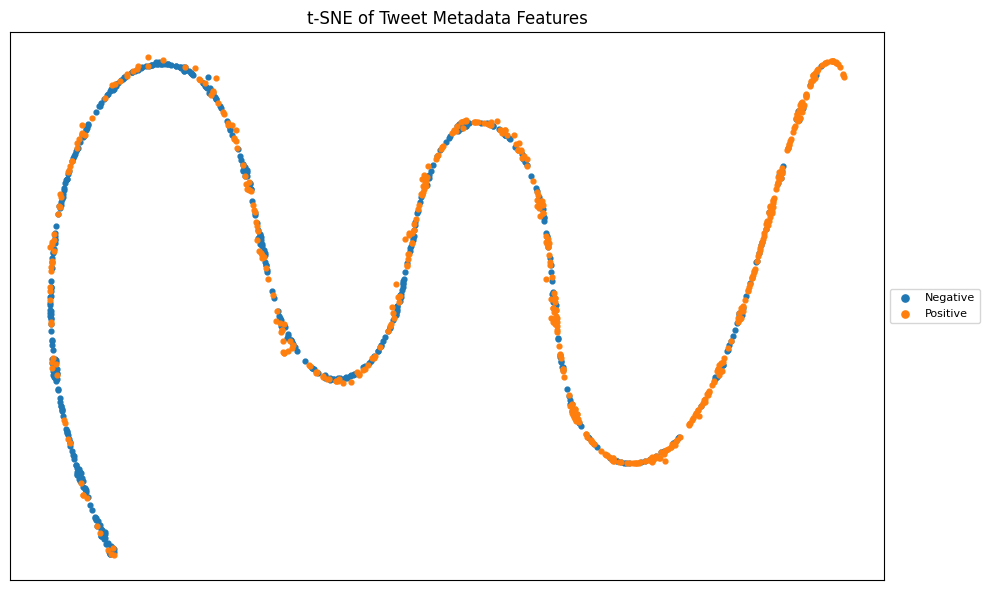

In [44]:
from sklearn.manifold import TSNE

def plot_tsne(X, y, title="t-SNE plot", class_names=None):
    selected_idx = []
    num_classes = len(np.unique(y))
    num_per_class = 500  # Number of samples to select per class
    title = "t-SNE of Tweet Metadata Features"
    class_names = ['Negative', 'Positive']
    for cls in range(num_classes):
        idx = np.where(y == cls)[0][:num_per_class]
        selected_idx.extend(idx)

    X_sub = X.iloc[selected_idx]
    y_sub = y.iloc[selected_idx]

    print("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    X_embedded = tsne.fit_transform(X_sub)

    # Plot
    plt.figure(figsize=(10, 6))
    for cls in range(num_classes):
        idx = y_sub == cls
        plt.scatter(X_embedded[idx, 0],
                    X_embedded[idx, 1],
                    s=12,
                    label=class_names[cls])

    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(markerscale=1.5, fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()
plot_tsne(features_train.drop(columns=['full_text']), y_train)

Running PCA...
Explained variance ratios: [9.99995637e-01 4.36121532e-06]
(1000,)
(1000,)


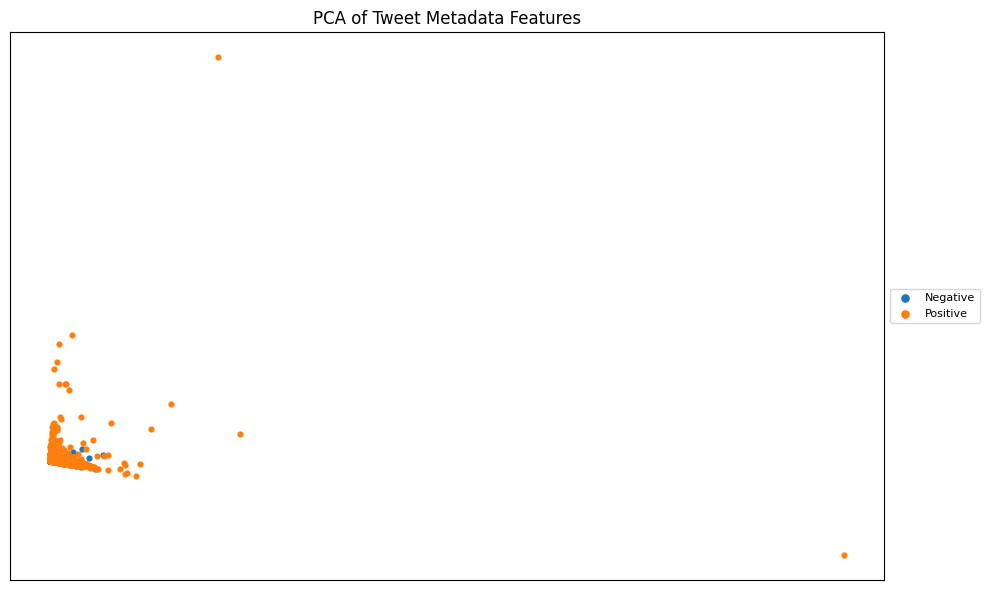

In [45]:
from sklearn.decomposition import PCA

def plot_PCA(X, y, title="PCA plot", class_names=None):
    selected_idx = []
    num_classes = len(np.unique(y_train))
    num_per_class = 500  # Number of samples to select per class
    title = "PCA of Tweet Metadata Features"
    class_names = ['Negative', 'Positive']

    # On bosse en NumPy pour éviter les problèmes d'index
    X_np = X if isinstance(X, np.ndarray) else X.to_numpy()
    y_np = y if isinstance(y, np.ndarray) else y.to_numpy()

    for cls in range(num_classes):
        idx = np.where(y_np == cls)[0][:num_per_class]
        selected_idx.extend(idx)

    X_sub = X_np[selected_idx]
    y_sub = y_np[selected_idx]

    print("Running PCA...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_sub)

    print("Explained variance ratios:", pca.explained_variance_ratio_)

    # Plot
    plt.figure(figsize=(10, 6))
    for cls in range(num_classes):
        idx = (y_sub == cls)
        print(idx.shape)
        plt.scatter(X_pca[idx, 0],
                    X_pca[idx, 1],
                    s=12,
                    label=class_names[cls])

    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(markerscale=1.5, fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()
plot_PCA(features_train.drop(columns=['full_text']), y_train)


In [33]:
feature_names = features_train.columns  # ou les noms de colonnes utilisées pour PCA

# Matrice des loadings: (n_features, n_components)
loadings = pca.components_.T

loadings_df = pd.DataFrame(loadings, index=feature_names, columns=["PC1", "PC2"])
print(loadings_df)

                                    PC1           PC2
is_quote                       0.000000  0.000000e+00
hour                          -0.014996  2.345457e-02
dayofweek                      0.027847 -3.526848e-02
is_quote                       0.000000 -5.551115e-17
source_group_automation        0.000535  6.847261e-03
source_group_instagram         0.997679 -1.331061e-02
source_group_linkedin          0.001532  9.699140e-01
source_group_media             0.002783  5.293095e-02
source_group_other             0.006128  8.906538e-02
source_group_scheduler         0.004409  7.211577e-02
source_group_twitter_official -0.059723 -2.024037e-01
source_group_unknown           0.001313  1.861262e-02


## Using the text with TF-IDF

In [104]:
def vectorize_text(df):
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words=stopwords.words('french'),
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.7
    )
    X_vectorized = vectorizer.fit_transform(df['full_text'])
    return X_vectorized, vectorizer

In [105]:
meta_cols = features_train.drop(columns=['full_text']).columns

X_meta_train = features_train[meta_cols].astype(float)
scaler = StandardScaler()
X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_test = features_test[meta_cols].astype(float)
X_meta_test_scaled = scaler.transform(X_meta_test)

X_train_text, vectorizer = vectorize_text(features_train)
X_test_text = vectorizer.transform(features_test['full_text'])

In [106]:
X_meta_train_scaled

array([[ 0.        ,  0.57407832, -0.40004557, ..., -0.18675913,
         0.2797613 , -0.04596914],
       [ 0.        ,  0.94320384,  0.13233789, ..., -0.18675913,
         0.2797613 , -0.04596914],
       [ 0.        , -0.717861  , -0.40004557, ..., -0.18675913,
        -3.57447583, -0.04596914],
       ...,
       [ 0.        ,  1.1277666 , -1.46481248, ..., -0.18675913,
         0.2797613 , -0.04596914],
       [ 0.        ,  1.1277666 , -0.93242903, ..., -0.18675913,
         0.2797613 , -0.04596914],
       [ 0.        ,  0.38951556, -0.40004557, ..., -0.18675913,
         0.2797613 , -0.04596914]])

In [122]:
from scipy.sparse import hstack
import numpy as np

X_train_final = hstack([X_train_text, X_meta_train_scaled])
X_test_final = hstack([X_test_text, X_meta_test_scaled])
X_kaggle_final = hstack([vectorizer.transform(features_kaggle['full_text']), scaler.transform(features_kaggle[meta_cols].astype(float))]) 
# X_train_final = X_meta_train_scaled
# X_test_final = X_meta_test_scaled
# X_train_final = X_train_text
# X_test_final = X_test_text

Running t-SNE...


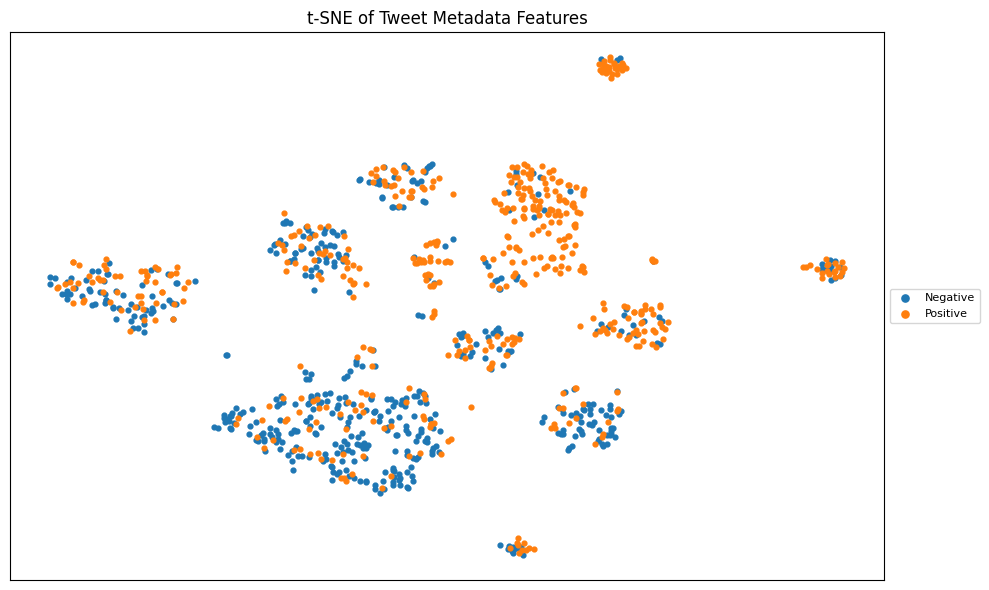

Running PCA...
Explained variance ratios: [0.1788821  0.17502051]
(1000,)
(1000,)


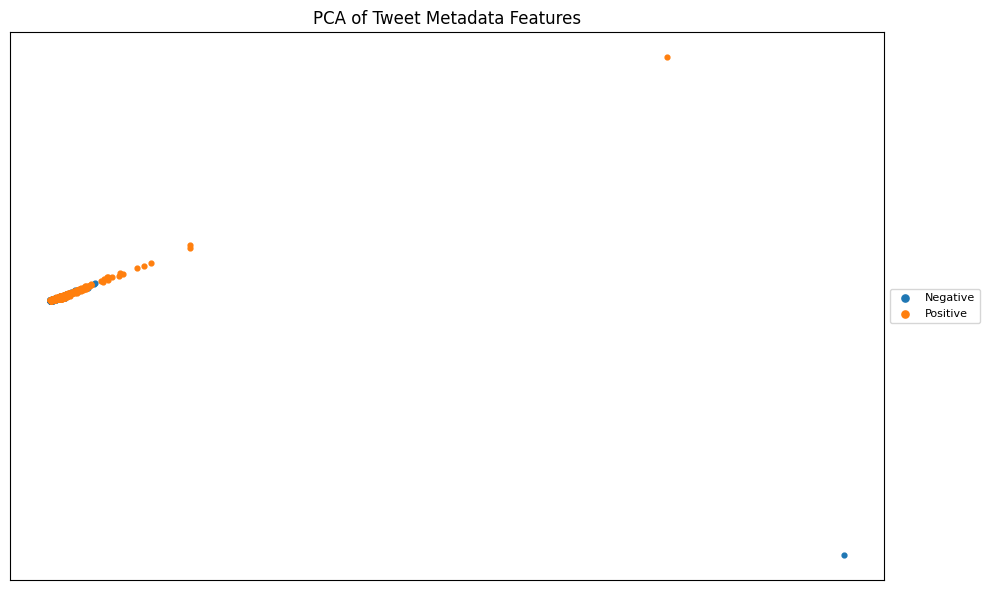

In [112]:
plot_tsne(pd.DataFrame(X_train_final.toarray()), y_train, title="t-SNE of Tweet Metadata Features")
plot_PCA(pd.DataFrame(X_train_final.toarray()), y_train, title="PCA of Tweet Metadata Features")

In [113]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=500,
    solver="liblinear",
)
clf.fit(X_train_final, y_train)

y_pred = clf.predict(X_test_final)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7965401497547121
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      8175
           1       0.83      0.71      0.77      7317

    accuracy                           0.80     15492
   macro avg       0.80      0.79      0.79     15492
weighted avg       0.80      0.80      0.79     15492



In [124]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=32,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.8318486961012135


In [126]:
def save_model(model):
    all_preds = model.predict(X_kaggle_final)
    print(all_preds)


    # création du fichier Kaggle
    output = pd.DataFrame({
        "ID": X_kaggle['challenge_id'],
        "Prediction": all_preds
    })

    output.to_csv("submission.csv", index=False)
    print("Submission saved.")

save_model(rf)

[1 1 0 ... 1 1 0]
Submission saved.


In [127]:
save_model(rf)

[1 1 0 ... 1 1 0]
Submission saved.


# Using Camembert